# Preprocessing

## 1. Consolidate individual datasets

### (a) Loading individual datasets

In [1]:
import pandas as pd
import os

# Check user is running this script from the 'engg2112' home directory.
current_folder = os.path.basename(os.getcwd())
if current_folder != "engg2112":
    print("Error: Please run this script from the 'engg2112' home directory.")
    exit()  # Stops the script immediately

FUEL_FILE = "datasets/fuel/NSW_E10_Full_Year_25_26.csv"
WEATHER_FILE = "datasets/weather/year_weather_dataset.csv"
OIL_FILE = "datasets/oil/daily oil price.xlsx"
TGP_FILE = "datasets/tgp/petrol_tgp.csv"
FX_FILE = "datasets/exchange/2023-current.xls"
COMPLETE_OUTPUT_FILE = "datasets/YEAR_COMPLETE_DATASET.csv"
MODEL_READY_OUTPUT_FILE = "datasets/MODEL_READY_DATASET.csv"

fuel_df = pd.read_csv(FUEL_FILE)
weather_df = pd.read_csv(WEATHER_FILE)
oil_df = pd.read_excel(OIL_FILE)
tgp_df = pd.read_csv(TGP_FILE)

# FX Data has unique formatting (metadata in top 11 rows)
fx_df_raw = pd.read_excel(FX_FILE, skiprows=1, nrows=0) # Get headers
fx_df = pd.read_excel(FX_FILE, skiprows=11, names=fx_df_raw.columns) # Get data

### (b) Standardising dates between datasets

In [2]:
# Convert Fuel Date - using mixed format and dayfirst for Australian/UK style dates
fuel_df['date'] = pd.to_datetime(
    fuel_df['PriceUpdatedDate'], 
    dayfirst=True, 
    format='mixed'
)

# Convert Weather Date
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Convert Oil Date
oil_df['date'] = pd.to_datetime(oil_df['date'])

# Convert TGP Date (First column is date)
tgp_date_col = tgp_df.columns[0]
tgp_df['date'] = pd.to_datetime(tgp_df[tgp_date_col])

# Convert FX Date (First column is date)
date_col = fx_df.columns[0]
fx_df['date'] = pd.to_datetime(fx_df[date_col], errors='coerce')

# fx dataset can be problematic; if datetime conversion fails, try Excel serial conversion
if fx_df['date'].isna().all():
    numeric_vals = pd.to_numeric(fx_df[date_col], errors='coerce')
    fx_df['date'] = pd.to_datetime(numeric_vals, unit='D', origin='1899-12-30')

# Drop rows that have no 'date' column (e.g., headers/footers) in this problematic csv
fx_df = fx_df.dropna(subset=['date'])

# Normalise all dates; so that time during day doesn't matter
df_list = [fuel_df, weather_df, oil_df, tgp_df, fx_df]
for df in df_list:
    df['date'] = df['date'].dt.normalize()

### (c) Rename and prepare columns for merging

In [3]:
oil_df = oil_df.rename(columns={'price': 'oil_price'})
tgp_df = tgp_df[['date', 'sydney_tgp']].rename(columns={'sydney_tgp': 'tgp_sydney'})

# Finding which column in fx_df.csv is the aud/usd column?
fx_col_candidates = [col for col in fx_df.columns if 'usd' in col.lower()]
if not fx_col_candidates:
    raise ValueError("Could not find AUD/USD column in FX dataset")

# There should just be one; either way take the first column as aud/usd
fx_col = fx_col_candidates[0]
fx_df = fx_df[['date', fx_col]].rename(columns={fx_col: 'aud_usd'})

# For adding a new column "region" into fuel_df
def assign_region(postcode):
    """Maps postcodes to your 6 specific weather regions"""
    try:
        p = int(postcode)
        if 2745 <= p <= 2780: return "Western_Sydney"
        elif (2170 <= p <= 2179) or (2560 <= p <= 2579): return "South_West_Sydney"
        elif (2250 <= p <= 2330) or (2280 <= p <= 2319): return "Hunter"
        elif 2500 <= p <= 2530: return "Wollongong"
        elif (2600 <= p <= 2620) or (2900 <= p <= 2914): return "Canberra"
        elif 2000 <= p <= 2199: return "Sydney_CBD"
        else: return "Regional"
    except:
        return "Regional"

# This is necessary so that can merge with weather_df, that only has region (not postcode)
fuel_df['Region'] = fuel_df['Postcode'].apply(assign_region)

### (d) Merging individual datasets 

In [4]:
# First merge fuel and weather df using the constructed 'Region' column
df_final = pd.merge(fuel_df, weather_df, on=['date', 'Region'], how='inner')

# Then, merge that with everything else using the standardised 'Date' column
df_final = pd.merge(df_final, oil_df, on='date', how='left')
df_final = pd.merge(df_final, tgp_df, on='date', how='left')
df_final = pd.merge(df_final, fx_df, on='date', how='left')

### (e) Filling weekend gaps in market data

In [5]:
# Market data (Oil, TGP, FX) is missing on weekends. 
# We fill forward so Saturday/Sunday uses Friday's price.
df_final = df_final.sort_values(by=['date', 'ServiceStationName'])
cols_to_fill = ['oil_price', 'tgp_sydney', 'aud_usd']
df_final[cols_to_fill] = df_final[cols_to_fill].ffill().bfill()

### (f) Saving complete dataset to output file

In [6]:
# Before saving, let's make all columns lowercase
df_final.columns = [col.lower() for col in df_final.columns]
df_final = df_final.rename(columns={'price': 'fuel_price'})

# And then do the save
output_dir = os.path.dirname(COMPLETE_OUTPUT_FILE)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
df_final.to_csv(COMPLETE_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {COMPLETE_OUTPUT_FILE} is ready.")
print("-" * 80)

df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/YEAR_COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 160447 entries, 63 to 160351
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   servicestationname  160447 non-null  object        
 1   address             160447 non-null  object        
 2   suburb              160447 non-null  object        
 3   postcode            160447 non-null  int64         
 4   brand               160447 non-null  object        
 5   fuelcode            160447 non-null  object        
 6   priceupdateddate    160447 non-null  object        
 7   fuel_price          160447 non-null  float64       
 8   date                160447 non-null  datetime64[ns]
 9   region              160447 non-null  object  

## 2. Generate feature columns

### (a') Plots for deciding Rolling Averages/Time Lags

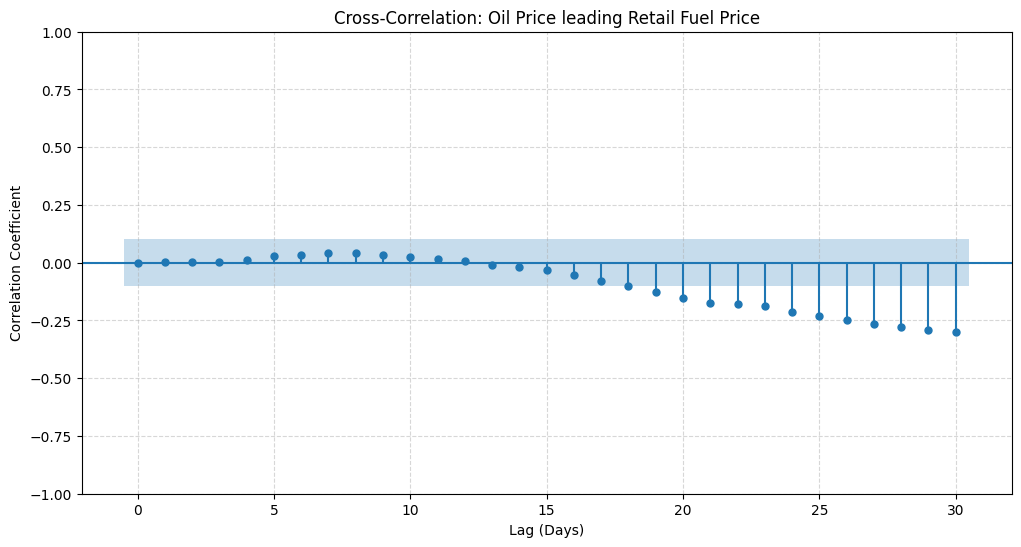

In [7]:
# import matplotlib.pyplot as plt
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# # Define the global/wholesale drivers you want to analyze
# external_drivers = {
#     'Oil Price (Brent/Global)': df_final.groupby('date')['oil_price'].mean(),
#     'TGP Sydney (Wholesale)': df_final.groupby('date')['tgp_sydney'].mean(),
#     'AUD-USD Exchange Rate': df_final.groupby('date')['aud_usd'].mean()
# }

# # Create a figure with a row for each variable
# fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# for i, (name, series) in enumerate(external_drivers.items()):
#     # Drop NaNs and ensure chronological order
#     series = series.dropna().sort_index()
    
#     # Calculate safe lags for this specific series
#     n_obs = len(series)
#     safe_lags = min(30, int(n_obs / 2) - 1)
    
#     # ACF: Shows the "Trend Persistence"
#     plot_acf(series, lags=safe_lags, ax=axes[i, 0], title=f"ACF: {name}")
    
#     # PACF: Shows the "Direct Memory"
#     plot_pacf(series, lags=safe_lags, ax=axes[i, 1], title=f"PACF: {name}")

# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import ccf
from statsmodels.graphics.tsaplots import plot_ccf

# 3. Now group and calculate the mean safely
df_daily = df_final.groupby('date').mean(numeric_only=True).sort_index()

# Extract your cleaned, synchronized signals
df_clean = df_daily[['oil_price', 'fuel_price']].dropna()

oil_signal = df_clean['oil_price']
fuel_signal = df_clean['fuel_price']

# 2. Plot the Cross-Correlation Function (CCF)
fig, ax = plt.subplots(figsize=(12, 6))

# Note: In statsmodels plot_ccf(x, y), it calculates correlation between X(t) and Y(t+k)
# So it shows how X (Oil) predicts Y (Fuel) at future lags
plot_ccf(oil_signal, fuel_signal, lags=30, ax=ax, alpha=0.05)

ax.set_title("Cross-Correlation: Oil Price leading Retail Fuel Price")
ax.set_xlabel("Lag (Days)")
ax.set_ylabel("Correlation Coefficient")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### (a) Daily and weekly average features

In [8]:
# For each (postcode, date) pair, what is the average of all prices; rows that have (postcode, date)
daily_avg_df = df_final.groupby(['postcode', 'date'])['fuel_price'].mean().reset_index()

# This is a new df isn't it; daily_avg_df. Rename the price column within this to postcode_daily_avg
daily_avg_df.rename(columns={'fuel_price': 'fuel_postcode_daily_avg'}, inplace=True)

# Sort to ensure the timeline is chronological for the rolling calculation
daily_avg_df = daily_avg_df.sort_values(['postcode', 'date'])

# We shift the average by 1 day so 'today' has access to 'yesterday's' price
daily_avg_df['fuel_postcode_price_lag_1'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].shift(1)

# Make new column that is 7-day rolling average
daily_avg_df['fuel_postcode_rolling_7d'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Drop rows where lag is NaN (the very first day of your dataset)
daily_avg_df = daily_avg_df.dropna(subset=['fuel_postcode_price_lag_1'])

# Merge new daily_avg_df with old df_final
df_final = df_final.merge(daily_avg_df, on=['postcode', 'date'], how='left')

### (b) Time lag features

In [9]:
# Making sure there is just one oil_price, tgp_sydney, and aud_usd for each date
lag_df = df_final.groupby('date')[['oil_price', 'tgp_sydney', 'aud_usd']].mean().reset_index()

# And sort by date so that can then calculate the time lag features
lag_df = lag_df.sort_values('date')

# These act as low-pass filters to smooth out daily global volatility.
lag_df['oil_rolling_7d'] = lag_df['oil_price'].rolling(window=7, min_periods=1).mean()
lag_df['tgp_rolling_7d'] = lag_df['tgp_sydney'].rolling(window=7, min_periods=1).mean()
lag_df['aud_usd_rolling_7d'] = lag_df['aud_usd'].rolling(window=7, min_periods=1).mean()

lag_df['oil_price_lag_1'] = lag_df['oil_price'].shift(1) # Yesterday
lag_df['tgp_sydney_lag_1'] = lag_df['tgp_sydney'].shift(1)
lag_df['aud_usd_lag_1'] = lag_df['aud_usd'].shift(1)

# Use fillna to fill in missing values (the first day and first week due to lag)
cols_to_fix = [
    'oil_price_lag_1', 'tgp_sydney_lag_1', 'aud_usd_lag_1',
    'oil_rolling_7d', 'tgp_rolling_7d', 'aud_usd_rolling_7d'
]
lag_df[cols_to_fix] = lag_df[cols_to_fix].bfill()

# Take the subset ['date' + cols_to_fix] of lag_df, and merge with original
df_final = df_final.merge(lag_df[['date'] + cols_to_fix], on='date', how='left')

### (c) Day-of-week feature

In [10]:
# Save as a number from 0 to 6 inclusive
df_final['day_of_week'] = df_final['date'].dt.dayofweek

### (d) Target feature

In [11]:
# 1. Calculate tomorrow's average price
daily_avg_df = daily_avg_df.sort_values(['postcode', 'date'])
daily_avg_df['target_fuel_price_tomorrow'] = daily_avg_df.groupby('postcode')['fuel_postcode_daily_avg'].shift(-1)

# 2. Safety Check: Get the date of that shifted price
daily_avg_df['target_date'] = daily_avg_df.groupby('postcode')['date'].shift(-1)

# 3. Only keep rows where the gap is exactly 1 day
# This prevents "jumping" over missing dates
is_consecutive = (daily_avg_df['target_date'] - daily_avg_df['date']).dt.days == 1
daily_avg_df = daily_avg_df[is_consecutive]

# 4. Merge the clean target back into df_final
df_final = df_final.merge(
    daily_avg_df[['postcode', 'date', 'target_fuel_price_tomorrow']], 
    on=['postcode', 'date'], 
    how='left'
)

# 5. Drop rows where no valid consecutive tomorrow exists
df_final = df_final.dropna(subset=['target_fuel_price_tomorrow'])

# Clean up temp column
daily_avg_df = daily_avg_df.drop(columns=['target_date'])

### (e) Saving model-ready dataset to output file

In [12]:
# Removing non-number and non-boolean columns; irrelevant to model training
cols_to_drop = [
    'servicestationname', 
    'address', 
    'suburb', 
    'region', 
    'date',
    'priceupdateddate',
    'brand',
    'fuelcode',
]
df_final = df_final.sort_values('date')
df_final = df_final.drop(columns=cols_to_drop)

# Remove identical rows
df_final = df_final.drop_duplicates()

df_final.to_csv(MODEL_READY_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {MODEL_READY_OUTPUT_FILE} is ready.")
print("-" * 80)
df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/MODEL_READY_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 94383 entries, 134 to 160294
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   postcode                    94383 non-null  int64  
 1   fuel_price                  94383 non-null  float64
 2   temp_max                    94383 non-null  float64
 3   temp_min                    94383 non-null  float64
 4   rainfall                    94383 non-null  float64
 5   oil_price                   94383 non-null  float64
 6   tgp_sydney                  94383 non-null  float64
 7   aud_usd                     94383 non-null  float64
 8   fuel_postcode_daily_avg     94383 non-null  float64
 9   fuel_postcode_price_lag_1   94383 non-null  flo

# Training

## 3. Initial modelling and comparison with baseline

### (a) Load model-ready dataset and do train-test split

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

# Load model-ready dataset
try:
    df = pd.read_csv(MODEL_READY_OUTPUT_FILE)
except NameError:
    print(f"Error: MODEL_READY_OUTPUT_FILE does not exist yet")
    print("Please run the 'Preprocessing' code block of this notebook")
    raise SystemExit

# Separate Features (X) and Target (y)
X = df.drop(columns=['target_fuel_price_tomorrow'])
y = df['target_fuel_price_tomorrow']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### (b) Train using Random Forest and Linear Regressor

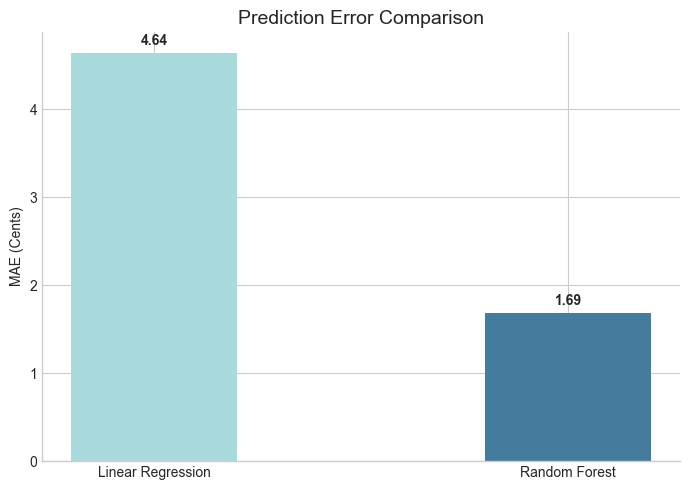

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, rf_predictions)
lr_mae = mean_absolute_error(y_test, lr_predictions)

plt.figure(figsize=(7, 5))
results = {'Linear Regression': lr_mae, 'Random Forest': rf_mae}
colors = ['#A8DADC', '#457B9D']

bars = plt.bar(results.keys(), results.values(), color=colors, width=0.4)

# Scientific styling
plt.title('Prediction Error Comparison', fontsize=14)
plt.ylabel('MAE (Cents)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### (c) Compare the two models

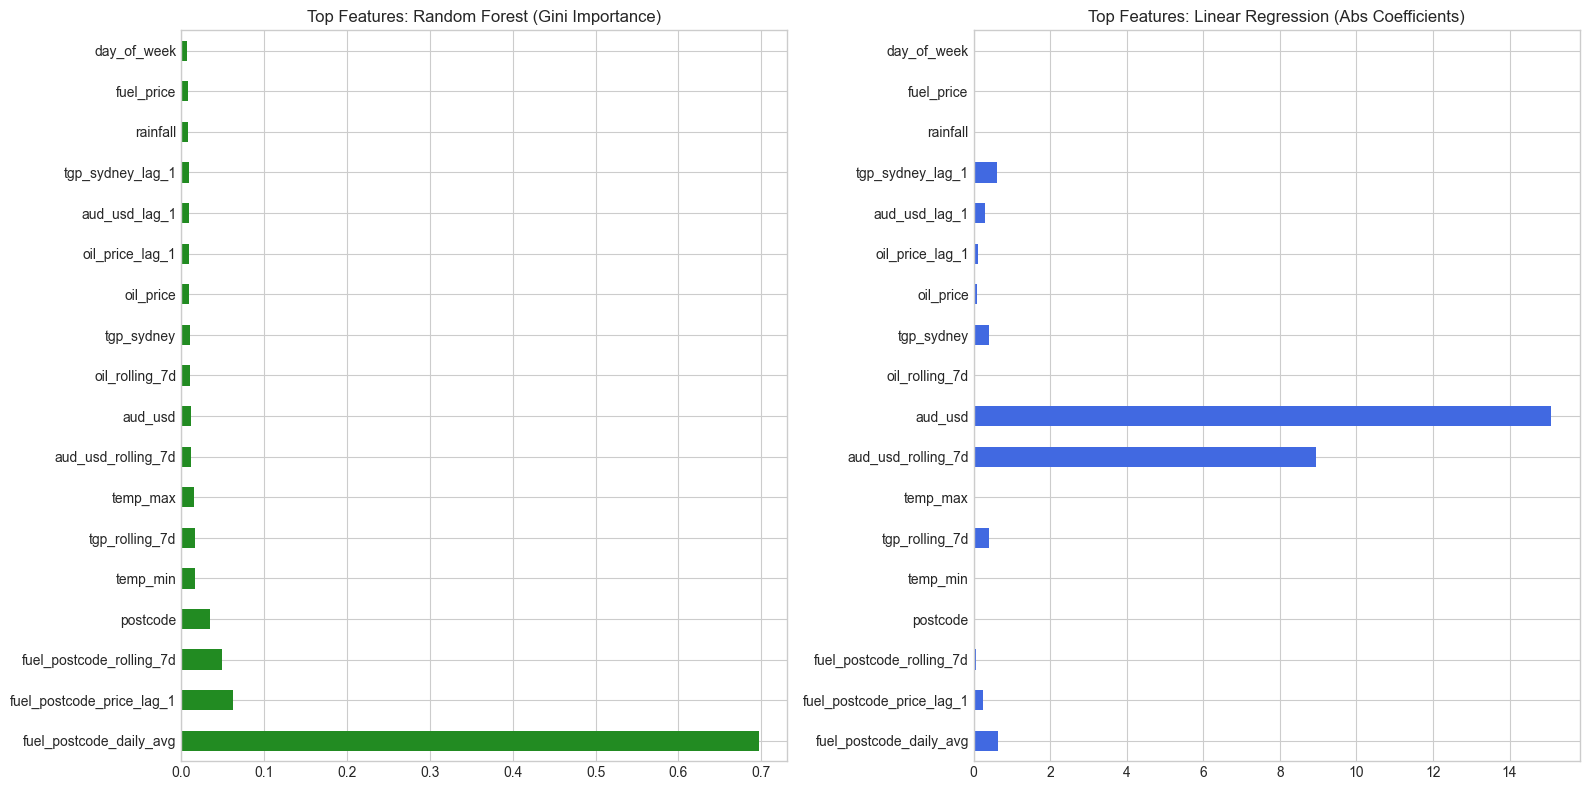

In [15]:
import pandas as pd
import numpy as np

# 1. Get RF Importances
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# 2. Get LR Coefficients (take absolute value to show magnitude of impact)
# We use absolute values because a large negative impact is still "important"
lr_importances = pd.Series(np.abs(lr_model.coef_), index=X_train.columns)

# Create a combined dataframe for plotting
importance_df = pd.DataFrame({
    'Random Forest': rf_importances,
    'Linear Regression': lr_importances
}).sort_values(by='Random Forest', ascending=False) # Sort by RF to see the difference

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

importance_df['Random Forest'].plot(kind='barh', ax=ax1, color='forestgreen')
ax1.set_title('Top Features: Random Forest (Gini Importance)')

importance_df['Linear Regression'].plot(kind='barh', ax=ax2, color='royalblue')
ax2.set_title('Top Features: Linear Regression (Abs Coefficients)')

plt.tight_layout()
plt.show()

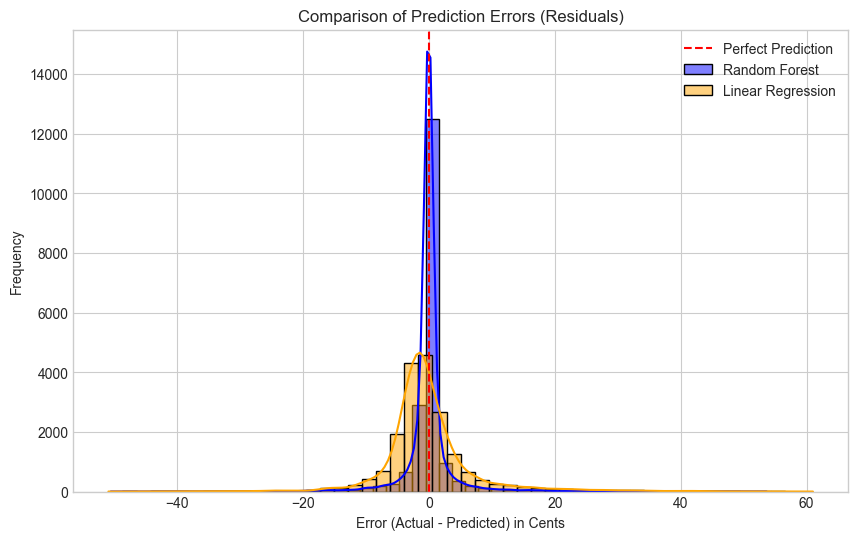

In [16]:
# Calculate residuals
rf_residuals = y_test - rf_predictions
lr_residuals = y_test - lr_predictions

plt.figure(figsize=(10, 6))

# Plot Random Forest Residuals
sns.histplot(rf_residuals, kde=True, bins=50, color='blue', label='Random Forest', alpha=0.5)

# Plot Linear Regression Residuals
sns.histplot(lr_residuals, kde=True, bins=50, color='orange', label='Linear Regression', alpha=0.5)

# Formatting
plt.title('Comparison of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction')
plt.legend() # This adds the labels to the plot
plt.show()

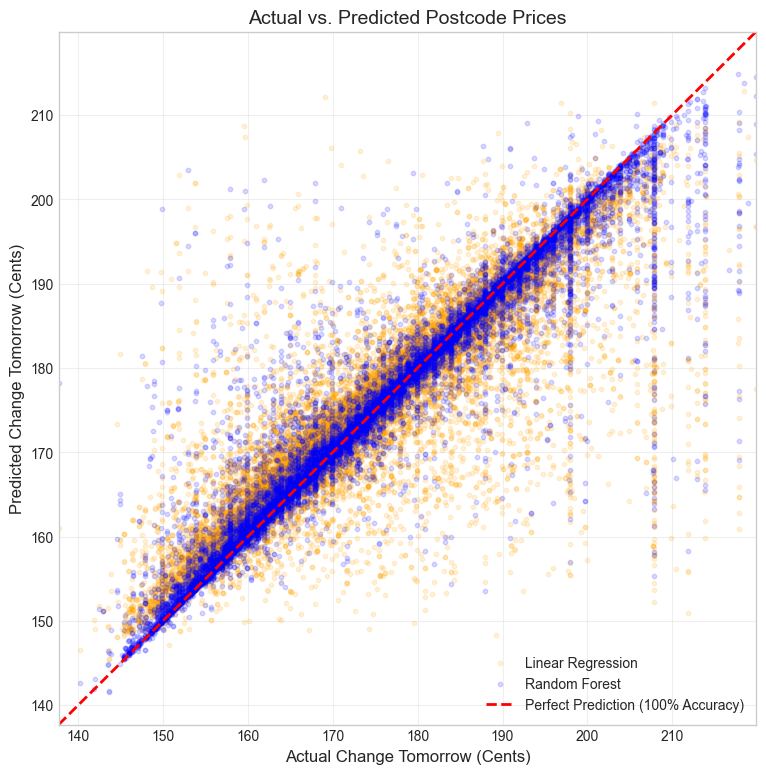

In [17]:
plt.figure(figsize=(9, 9))

# Plot Linear Regression
plt.scatter(y_test, lr_predictions, alpha=0.15, color='orange', label='Linear Regression', s=10)

# Plot Random Forest
plt.scatter(y_test, rf_predictions, alpha=0.15, color='blue', label='Random Forest', s=10)

# Perfect Prediction Line
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction (100% Accuracy)')

# Refined Labels for the Delta approach
plt.title('Actual vs. Predicted Postcode Prices', fontsize=14)
plt.xlabel('Actual Change Tomorrow (Cents)', fontsize=12)
plt.ylabel('Predicted Change Tomorrow (Cents)', fontsize=12)

# Add a horizontal and vertical line at zero to show the "No Change" boundary
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)

plt.xlim(line_range)
plt.ylim(line_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

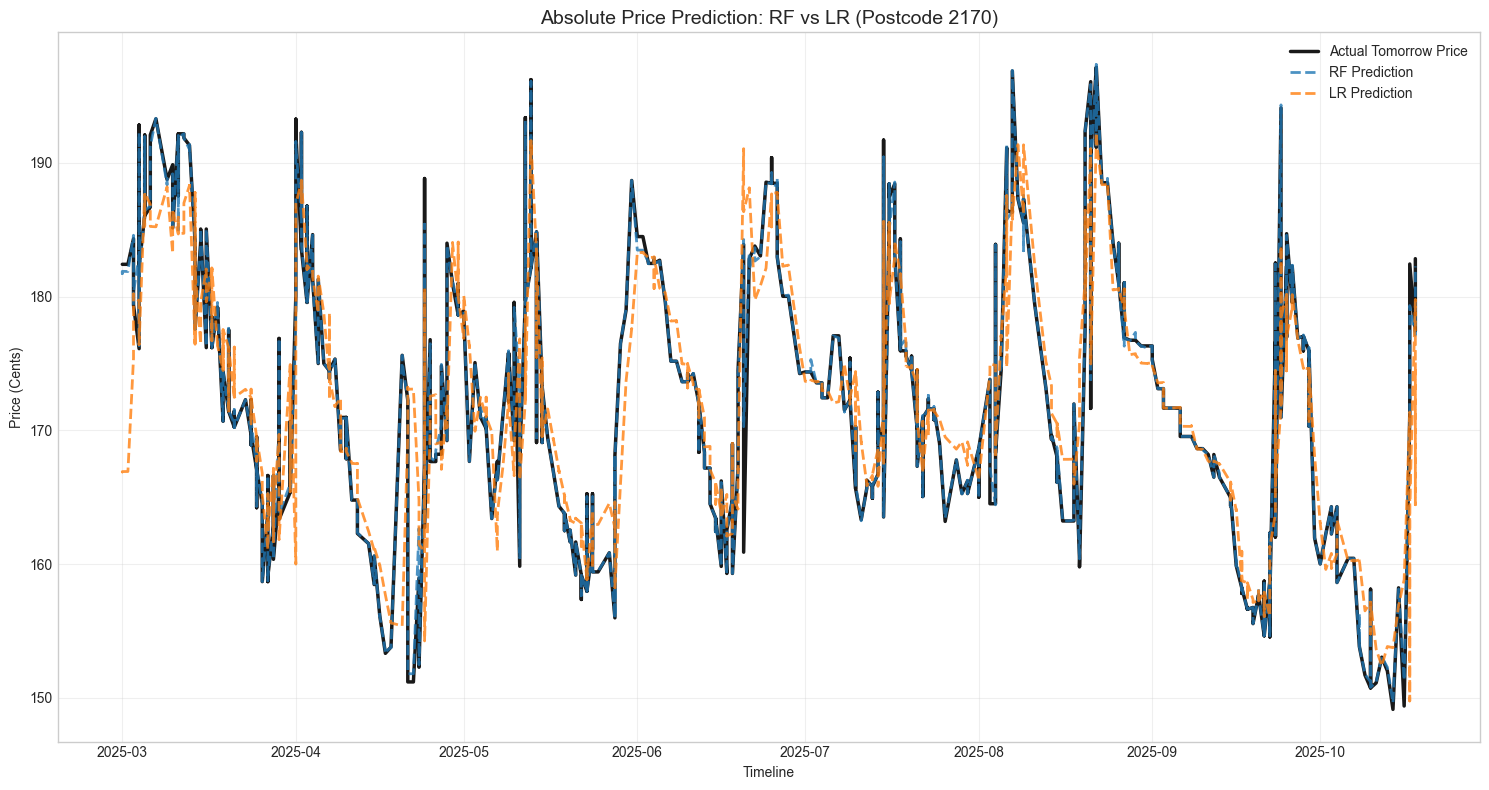

In [18]:
# 1. Reconstruct the test results with dates
# Assuming 'df_final' or your source CSV still exists with the 'date' column
df_source = pd.read_csv(COMPLETE_OUTPUT_FILE, parse_dates=['date'])

comparison_df = pd.DataFrame({
    'date': df_source.loc[X_test.index, 'date'],
    'postcode': X_test['postcode'],
    'actual': y_test,
    'rf_pred': rf_predictions,
    'lr_pred': lr_predictions
})

# 2. Pick a sample postcode
sample_postcode = comparison_df['postcode'].mode()[0]
plot_data = comparison_df[comparison_df['postcode'] == sample_postcode].sort_values('date')

# 3. Create the Comparison Plot
plt.figure(figsize=(15, 8))

# Actual price
plt.plot(plot_data['date'], plot_data['actual'], 
         label='Actual Tomorrow Price', color='black', lw=2.5, linestyle='-', alpha=0.9)

# Random Forest
plt.plot(plot_data['date'], plot_data['rf_pred'], 
         label='RF Prediction', color='#1f77b4', linestyle='--', alpha=0.8, lw=2)

# Linear Regression
plt.plot(plot_data['date'], plot_data['lr_pred'], 
         label='LR Prediction', color='#ff7f0e', linestyle='--', alpha=0.8, lw=2)

# REMOVED: plt.axhline(0) - No longer needed for absolute prices

plt.title(f'Absolute Price Prediction: RF vs LR (Postcode {sample_postcode})', fontsize=14)
plt.ylabel('Price (Cents)') # Updated label
plt.xlabel('Timeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

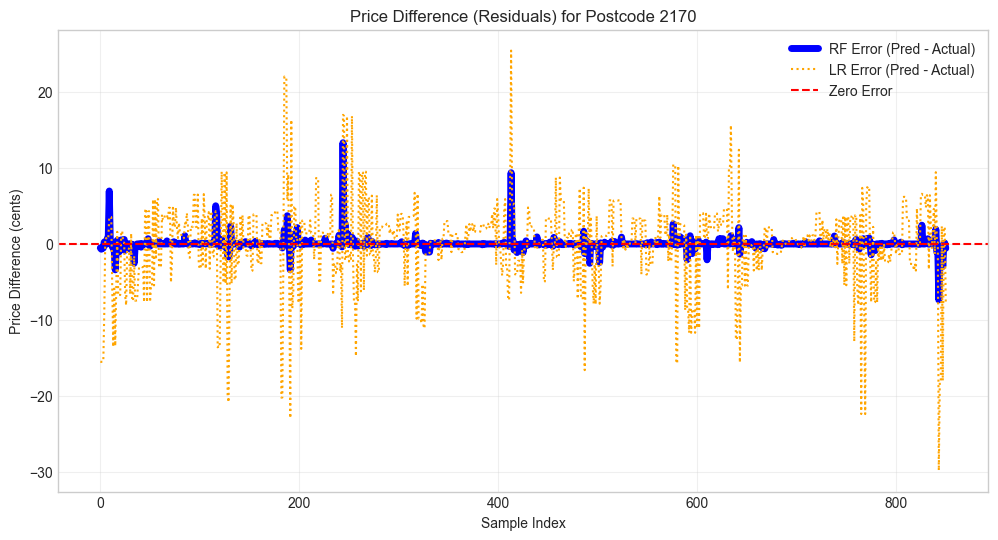

In [19]:
# Calculate the differences (Residuals)
plot_data['rf_diff'] = plot_data['rf_pred'] - plot_data['actual']
plot_data['lr_diff'] = plot_data['lr_pred'] - plot_data['actual']

plt.figure(figsize=(12, 6))

# Plotting the difference from zero
plt.plot(plot_data['rf_diff'].values, label='RF Error (Pred - Actual)', color='blue', lw=5, linestyle="-")
plt.plot(plot_data['lr_diff'].values, label='LR Error (Pred - Actual)', color='orange', linestyle=":")

# Add a zero line to represent perfect prediction
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.title(f'Price Difference (Residuals) for Postcode {sample_postcode}')
plt.xlabel('Sample Index')
plt.ylabel('Price Difference (cents)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
